In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('results', exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow: 2.20.0
Libraries loaded successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/ai_project_synthetic_datasets-20260505T171228Z-3-001/ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv'

df = pd.read_csv(path)
print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Mounted at /content/drive
Dataset loaded!
Shape: (2000, 17)

Column names:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


In [3]:
print("=" * 55)
print("DATASET UNDERSTANDING")
print("=" * 55)

print(f"\nTotal Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistical Summary:")
display(df.describe())

print(f"\nTarget Column - Churn Distribution:")
print(df['churn'].value_counts())
print(f"Churn Rate: {df['churn'].mean()*100:.2f}%")

DATASET UNDERSTANDING

Total Rows    : 2000
Total Columns : 17

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_c

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



Target Column - Churn Distribution:
churn
0    1969
1      31
Name: count, dtype: int64
Churn Rate: 1.55%


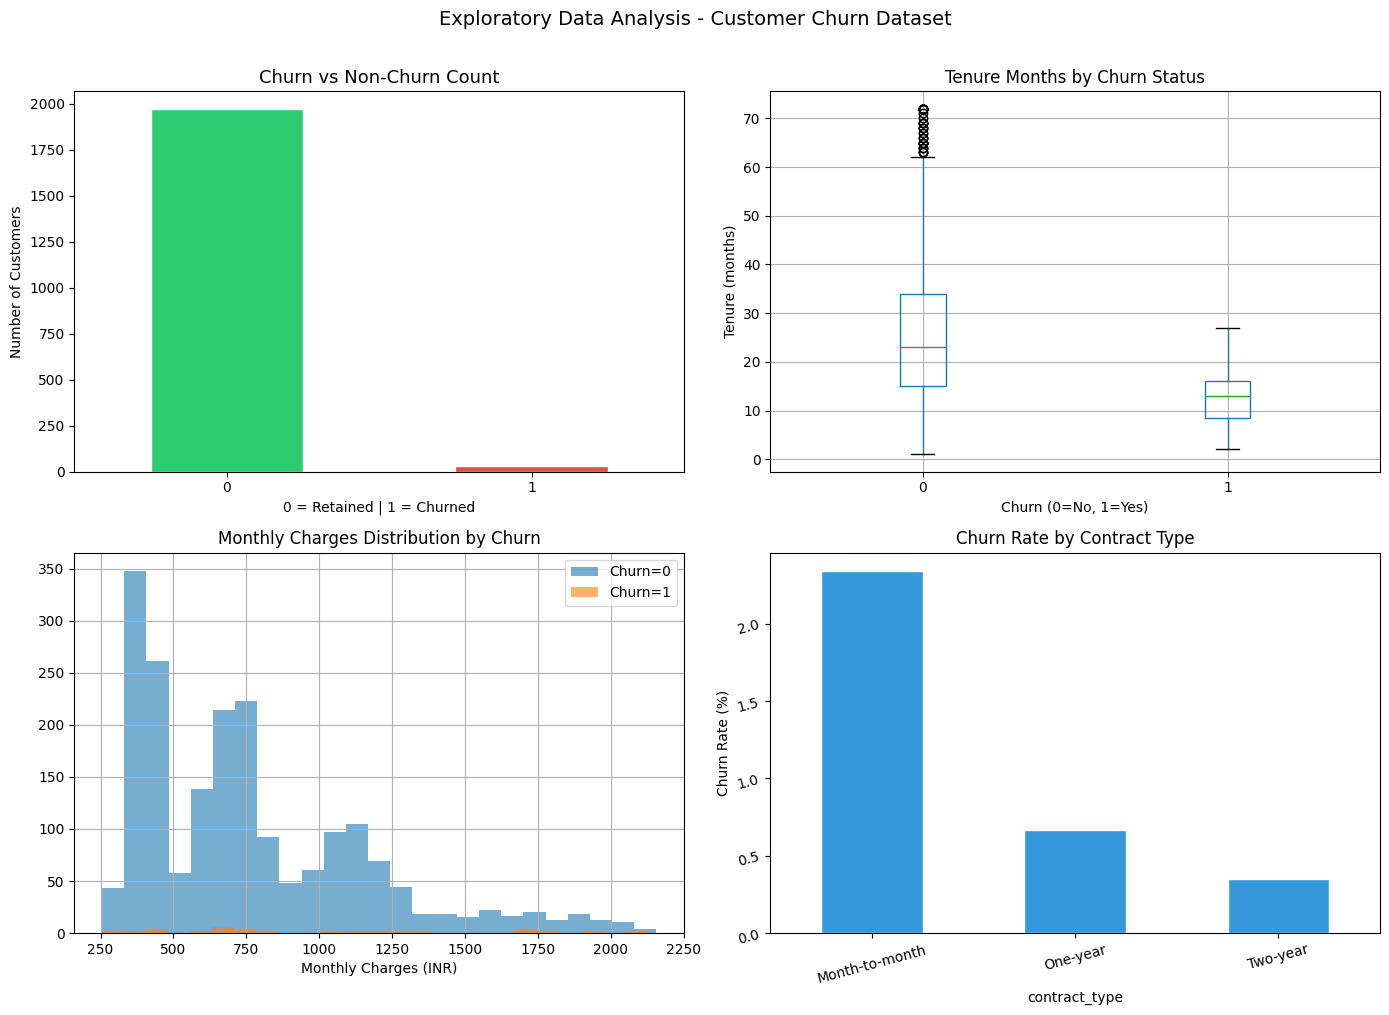

EDA plots saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 - Target distribution
df['churn'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Churn vs Non-Churn Count', fontsize=13)
axes[0,0].set_xlabel('0 = Retained | 1 = Churned')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(rotation=0)

# Plot 2 - Tenure vs Churn
df.boxplot(column='tenure_months', by='churn', ax=axes[0,1])
axes[0,1].set_title('Tenure Months by Churn Status')
axes[0,1].set_xlabel('Churn (0=No, 1=Yes)')
axes[0,1].set_ylabel('Tenure (months)')

# Plot 3 - Monthly charges histogram
for label, grp in df.groupby('churn'):
    grp['monthly_charges_inr'].hist(
        alpha=0.6, bins=25, ax=axes[1,0],
        label=f"Churn={label}")
axes[1,0].set_title('Monthly Charges Distribution by Churn')
axes[1,0].set_xlabel('Monthly Charges (INR)')
axes[1,0].legend()

# Plot 4 - Contract type churn rate
churn_by_contract = df.groupby('contract_type')['churn'].mean() * 100
churn_by_contract.plot(kind='bar', ax=axes[1,1], color='#3498db', edgecolor='white')
axes[1,1].set_title('Churn Rate by Contract Type')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(rotation=15)

plt.suptitle('Exploratory Data Analysis - Customer Churn Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [5]:
df_clean = df.copy()

# Drop identifier column
df_clean.drop('customer_id', axis=1, inplace=True)

# Encode categorical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method', 'autopay_enabled']
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Categorical encoding done!")

# Features and target
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Train-test split (85-15 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=7, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train_scaled.shape[0]}")
print(f"Testing samples  : {X_test_scaled.shape[0]}")
print(f"Features         : {X_train_scaled.shape[1]}")
print(f"\nTrain churn rate : {y_train.mean()*100:.2f}%")
print(f"Test churn rate  : {y_test.mean()*100:.2f}%")

Categorical encoding done!

Training samples : 1700
Testing samples  : 300
Features         : 15

Train churn rate : 1.53%
Test churn rate  : 1.67%


In [6]:
def build_model(hidden_layers=3, neurons=128, learning_rate=0.0005, activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    for i in range(hidden_layers):
        model.add(layers.Dense(neurons // (2**i), activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

print(f"\nFinal Train Accuracy : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy   : {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5377 - loss: 0.8906 - val_accuracy: 0.3647 - val_loss: 0.7282
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5606 - loss: 0.8063 - val_accuracy: 0.8353 - val_loss: 0.6254
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5827 - loss: 0.7546 - val_accuracy: 0.9608 - val_loss: 0.5568
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6111 - loss: 0.7012 - val_accuracy: 0.9843 - val_loss: 0.5059
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6408 - loss: 0.6519 - val_accuracy: 0.9882 - val_loss: 0.4745
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6886 - loss: 0.6113 - val_accuracy: 0.9922 - val_loss: 0.4460
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7066 - loss: 0.5799 - val_accuracy: 0.9922 - val_loss: 0.4160
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7405 - loss: 0.5555 - val_accuracy: 0.9922 - val_loss

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Test Accuracy: 98.33%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       295
     Churned       0.00      0.00      0.00         5

    accuracy                           0.98       300
   macro avg       0.49      0.50      0.50       300
weighted avg       0.97      0.98      0.98       300



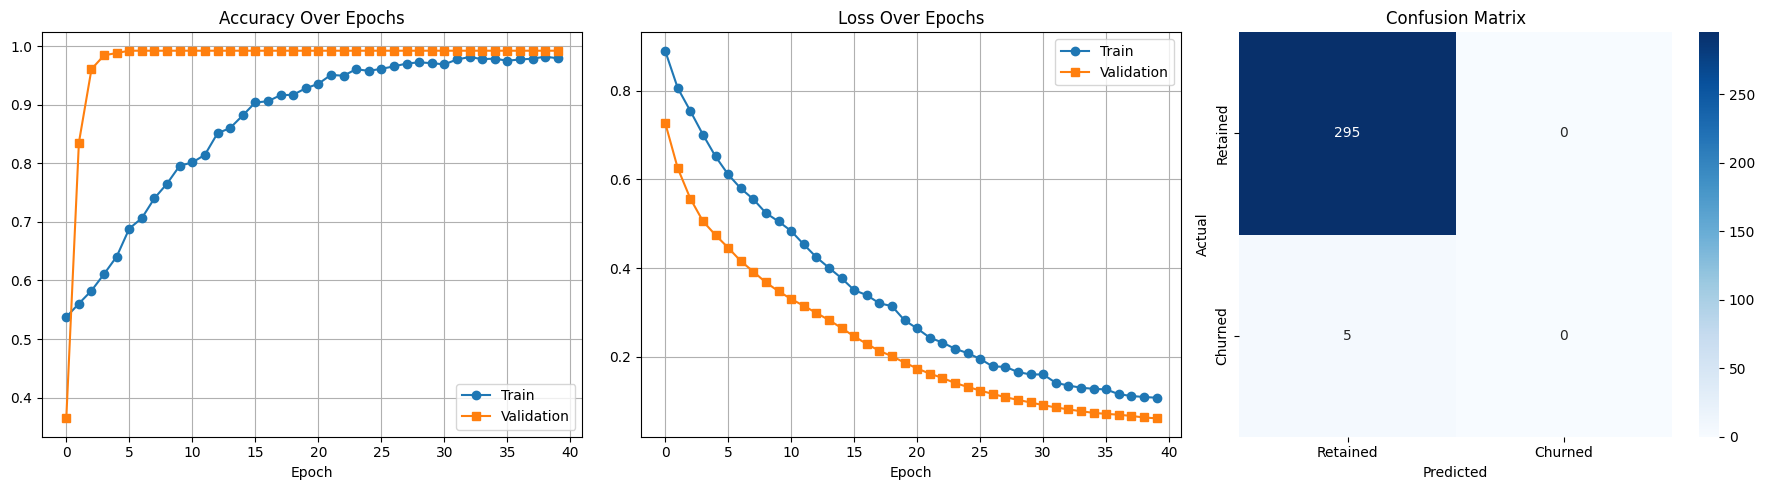

Evaluation plots saved!


In [8]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=100, bbox_inches='tight')
plt.show()
print("Evaluation plots saved!")

In [9]:
experiments = [
    {'name': 'Config A - Default',     'hidden_layers': 3, 'neurons': 128, 'lr': 0.0005, 'batch': 64, 'epochs': 40, 'activation': 'relu'},
    {'name': 'Config B - Wider Net',   'hidden_layers': 3, 'neurons': 256, 'lr': 0.0005, 'batch': 64, 'epochs': 40, 'activation': 'relu'},
    {'name': 'Config C - Shallow',     'hidden_layers': 1, 'neurons': 128, 'lr': 0.0005, 'batch': 64, 'epochs': 40, 'activation': 'relu'},
    {'name': 'Config D - Higher LR',   'hidden_layers': 3, 'neurons': 128, 'lr': 0.01,   'batch': 64, 'epochs': 40, 'activation': 'relu'},
    {'name': 'Config E - Small Batch', 'hidden_layers': 3, 'neurons': 128, 'lr': 0.0005, 'batch': 16, 'epochs': 40, 'activation': 'relu'},
]

results_list = []
for exp in experiments:
    print(f"Running: {exp['name']} ...")
    m = build_model(exp['hidden_layers'], exp['neurons'], exp['lr'], exp['activation'])
    h = m.fit(X_train_scaled, y_train,
              epochs=exp['epochs'], batch_size=exp['batch'],
              validation_split=0.15, verbose=0)
    yp = (m.predict(X_test_scaled) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, yp)
    val_acc = max(h.history['val_accuracy'])
    results_list.append({
        'Config': exp['name'],
        'Layers': exp['hidden_layers'],
        'Neurons': exp['neurons'],
        'Learning Rate': exp['lr'],
        'Batch Size': exp['batch'],
        'Val Accuracy': round(val_acc, 4),
        'Test Accuracy': round(acc, 4)
    })
    print(f"  Done | Test Acc: {acc*100:.2f}%")

results_df = pd.DataFrame(results_list)
print("\n" + "="*60)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("="*60)
display(results_df)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print("Saved!")

Running: Config A - Default ...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
  Done | Test Acc: 98.33%
Running: Config B - Wider Net ...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
  Done | Test Acc: 98.33%
Running: Config C - Shallow ...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
  Done | Test Acc: 98.33%
Running: Config D - Higher LR ...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
  Done | Test Acc: 98.33%
Running: Config E - Small Batch ...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
  Done | Test Acc: 98.33%

HYPERPARAMETER EXPERIMENT RESULTS


,Config,Layers,Neurons,Learning Rate,Batch Size,Val Accuracy,Test Accuracy
0,Config A - Default,3,128,0.0005,64,0.9922,0.9833
1,Config B - Wider Net,3,256,0.0005,64,0.9922,0.9833
2,Config C - Shallow,1,128,0.0005,64,0.9922,0.9833
3,Config D - Higher LR,3,128,0.0100,64,0.9922,0.9833
4,Config E - Small Batch,3,128,0.0005,16,0.9922,0.9833


Saved!


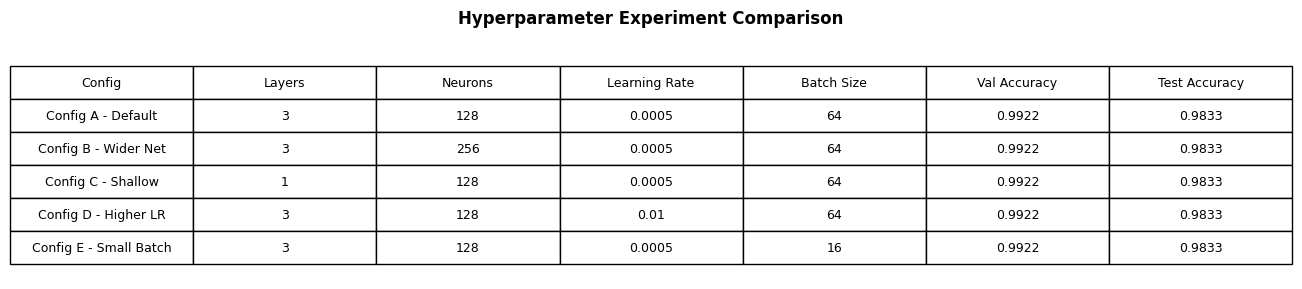

Comparison table image saved!


In [10]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')
tbl = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.0)
plt.title('Hyperparameter Experiment Comparison', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=120, bbox_inches='tight')
plt.show()
print("Comparison table image saved!")

In [11]:
from google.colab import files

files.download('results/eda_plots.png')
files.download('results/evaluation_outputs.png')
files.download('results/model_comparison_table.png')
files.download('results/model_comparison_table.csv')

print("\nAb notebook download karo:")
print("File → Download → Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Ab notebook download karo:
File → Download → Download .ipynb
